In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel('C:\\Users\\abdo\\Desktop\\Bike Purchase Analysis\\Excel Project Dataset.xlsx')
df.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,M,F,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,No
1,24107,M,M,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,No
2,14177,M,M,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,No
3,24381,S,M,70000,0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Yes
4,25597,S,M,30000,0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1026 entries, 0 to 1025
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ID                1026 non-null   int64
 1   Marital Status    1026 non-null   str  
 2   Gender            1026 non-null   str  
 3   Income            1026 non-null   int64
 4   Children          1026 non-null   int64
 5   Education         1026 non-null   str  
 6   Occupation        1026 non-null   str  
 7   Home Owner        1026 non-null   str  
 8   Cars              1026 non-null   int64
 9   Commute Distance  1026 non-null   str  
 10  Region            1026 non-null   str  
 11  Age               1026 non-null   int64
 12  Purchased Bike    1026 non-null   str  
dtypes: int64(5), str(8)
memory usage: 104.3 KB


In [6]:
df.isnull().sum()

ID                  0
Marital Status      0
Gender              0
Income              0
Children            0
Education           0
Occupation          0
Home Owner          0
Cars                0
Commute Distance    0
Region              0
Age                 0
Purchased Bike      0
dtype: int64

In [7]:
df["Gender"].unique()

<StringArray>
['F', 'M']
Length: 2, dtype: str

In [9]:
df["Gender"] = df["Gender"].replace({
    "M": "Male",
    "F": "Female"
})

In [10]:
df["Gender"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [11]:
df["Marital Status"] = df["Marital Status"].replace({
    "S": "Single",
    "M": "Married"
})
df["Marital Status"].unique()

<StringArray>
['Married', 'Single']
Length: 2, dtype: str

In [12]:
def age_group(age):

    if age >= 25 and age <= 39:
        return "Young"

    elif age >= 40 and age <= 59:
        return "Middle-aged"

    else:
        return "Senior"

In [14]:
df["Age Group"] = df["Age"].apply(age_group)

In [17]:
df["Age"].apply(age_group)

0       Middle-aged
1       Middle-aged
2            Senior
3       Middle-aged
4             Young
           ...     
1021          Young
1022         Senior
1023          Young
1024          Young
1025    Middle-aged
Name: Age, Length: 1026, dtype: str

In [18]:
df["Age Group"]

0       Middle-aged
1       Middle-aged
2            Senior
3       Middle-aged
4             Young
           ...     
1021          Young
1022         Senior
1023          Young
1024          Young
1025    Middle-aged
Name: Age Group, Length: 1026, dtype: str

In [19]:
df.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike,Age Group
0,12496,Married,Female,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,No,Middle-aged
1,24107,Married,Male,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,No,Middle-aged
2,14177,Married,Male,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,No,Senior
3,24381,Single,Male,70000,0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Yes,Middle-aged
4,25597,Single,Male,30000,0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,Yes,Young


In [ ]:
df.groupby("Age Group")["Purchased Bike"].value_counts()

Age Group    Purchased Bike
Middle-aged  No                277
             Yes               236
Senior       No                 80
             Yes                37
Young        Yes               222
             No                174
Name: count, dtype: int64

In [22]:
df.groupby("Purchased Bike")["Income"].mean()

Purchased Bike
No     55028.248588
Yes    57474.747475
Name: Income, dtype: float64

In [23]:
df.groupby("Gender")["Purchased Bike"].value_counts()

Gender  Purchased Bike
Female  No                258
        Yes               243
Male    No                273
        Yes               252
Name: count, dtype: int64

In [24]:
df.groupby("Commute Distance")["Purchased Bike"].value_counts()

Commute Distance  Purchased Bike
0-1 Miles         Yes               207
                  No                171
1-2 Miles         No                 93
                  Yes                83
10+ Miles         No                 80
                  Yes                33
2-5 Miles         Yes                95
                  No                 67
5-10 Miles        No                120
                  Yes                77
Name: count, dtype: int64

In [25]:
df.groupby("Cars")["Purchased Bike"].value_counts()

Cars  Purchased Bike
0     Yes               153
      No                101
1     Yes               159
      No                118
2     No                219
      Yes               129
3     No                 53
      Yes                33
4     No                 40
      Yes                21
Name: count, dtype: int64

In [26]:
df.groupby("Age Group")["Purchased Bike"].value_counts()

Age Group    Purchased Bike
Middle-aged  No                277
             Yes               236
Senior       No                 80
             Yes                37
Young        Yes               222
             No                174
Name: count, dtype: int64

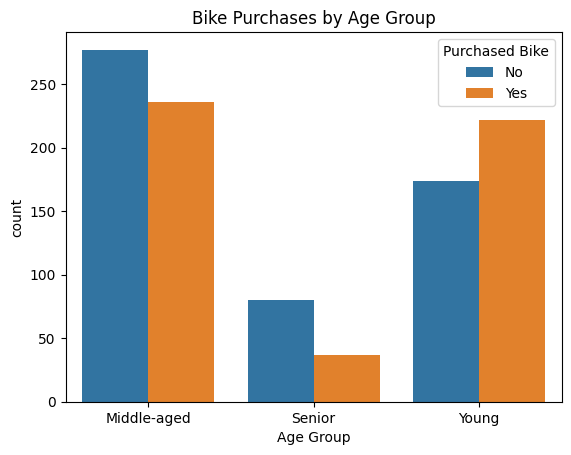

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="Age Group",
    hue="Purchased Bike"
)

plt.title("Bike Purchases by Age Group")
plt.savefig("Age_Group_Bike_Purchases.png", bbox_inches='tight')
plt.show()

In [28]:
df["Purchased Bike"].value_counts()

Purchased Bike
No     531
Yes    495
Name: count, dtype: int64

In [29]:
df.groupby("Occupation")["Purchased Bike"].value_counts()

Occupation      Purchased Bike
Clerical        Yes                95
                No                 92
Management      No                101
                Yes                73
Manual          No                 67
                Yes                59
Professional    Yes               150
                No                130
Skilled Manual  No                141
                Yes               118
Name: count, dtype: int64

In [30]:
df.groupby("Region")["Purchased Bike"].value_counts()

Region         Purchased Bike
Europe         No                160
               Yes               156
North America  No                288
               Yes               220
Pacific        Yes               119
               No                 83
Name: count, dtype: int64

In [31]:
df.groupby("Education")["Purchased Bike"].value_counts()

Education            Purchased Bike
Bachelors            Yes               169
                     No                142
Graduate Degree      Yes                95
                     No                 80
High School          No                102
                     Yes                82
Partial College      No                151
                     Yes               127
Partial High School  No                 56
                     Yes                22
Name: count, dtype: int64

In [32]:
df.groupby("Home Owner")["Purchased Bike"].value_counts()

Home Owner  Purchased Bike
No          No                166
            Yes               163
Yes         No                365
            Yes               332
Name: count, dtype: int64

In [33]:
df.groupby("Children")["Purchased Bike"].value_counts()

Children  Purchased Bike
0         Yes               146
          No                143
1         Yes                98
          No                 74
2         No                115
          Yes               104
3         Yes                75
          No                 61
4         No                 72
          Yes                54
5         No                 66
          Yes                18
Name: count, dtype: int64

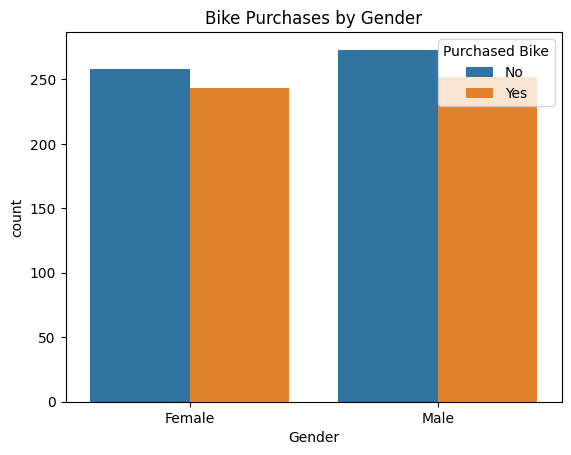

In [46]:
sns.countplot(
    data=df,
    x="Gender",
    hue="Purchased Bike"
)

plt.title("Bike Purchases by Gender")
plt.savefig("Gender_Bike_Purchases.png", bbox_inches='tight')
plt.show()

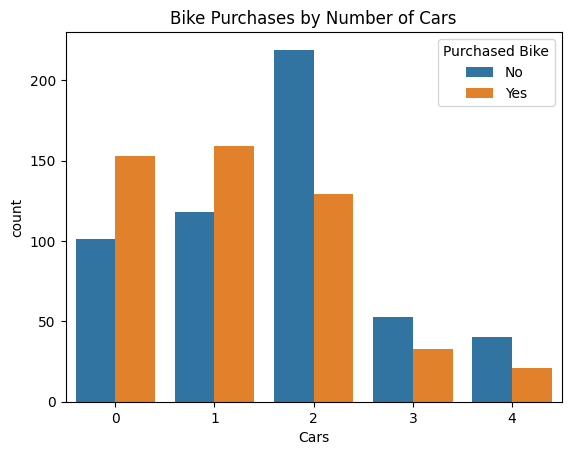

In [45]:
sns.countplot(
    data=df,
    x="Cars",
    hue="Purchased Bike"
)

plt.title("Bike Purchases by Number of Cars")
plt.savefig("Cars_Bike_Purchases.png", bbox_inches='tight')
plt.show()

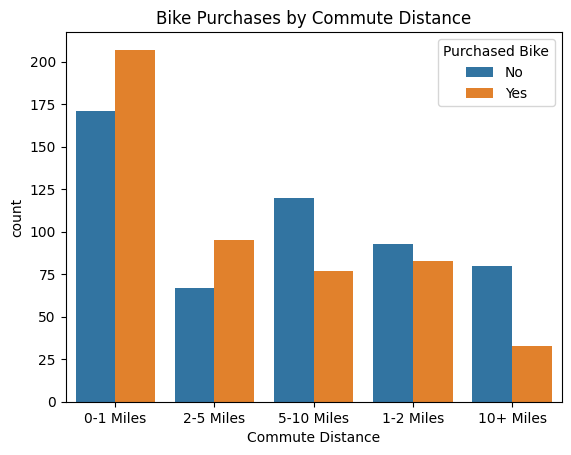

In [44]:
sns.countplot(
    data=df,
    x="Commute Distance",
    hue="Purchased Bike"
)

plt.title("Bike Purchases by Commute Distance")
plt.savefig("Commute_Distance_Bike_Purchases.png", bbox_inches='tight')
plt.show()

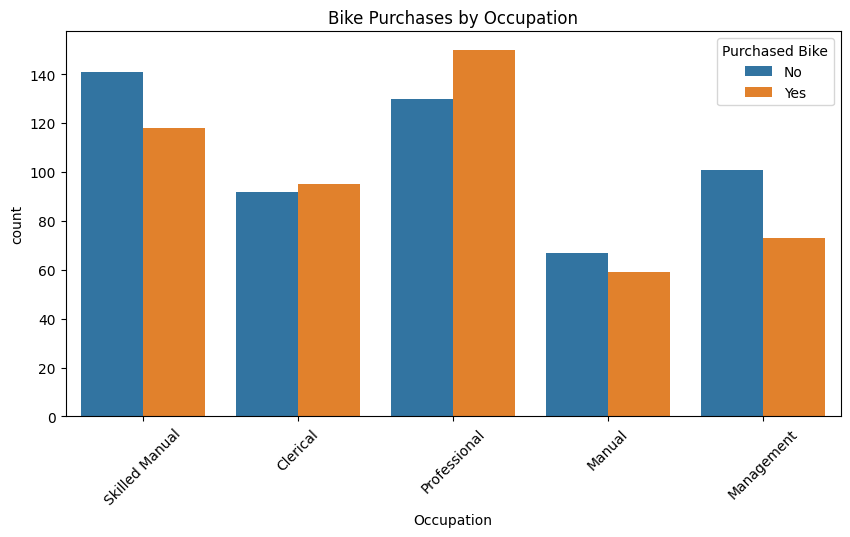

In [43]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Occupation",
    hue="Purchased Bike"
)

plt.xticks(rotation=45)

plt.title("Bike Purchases by Occupation")
plt.savefig("Occupation_Bike_Purchases.png", bbox_inches='tight')
plt.show()

In [40]:
df.to_csv("cleaned_bike_data.csv", index=False)